In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/comment-category-prediction-challenge/Sample.csv
/kaggle/input/comment-category-prediction-challenge/train.csv
/kaggle/input/comment-category-prediction-challenge/test.csv
/kaggle/input/models/aditibindal/best-lgbm-model/scikitlearn/default/1/lgbm_best_model.pkl


## Setup and Load Data

In [2]:
import pandas as pd
import numpy as np

In [3]:
X = pd.read_csv('/kaggle/input/comment-category-prediction-challenge/train.csv')
X_test = pd.read_csv('/kaggle/input/comment-category-prediction-challenge/test.csv')

In [4]:
X.shape

(198000, 15)

In [5]:
X_test.shape

(102000, 14)

## Data Inspection and Cleaning

### Data Type inspection

In [6]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 198000 entries, 0 to 197999
Data columns (total 15 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   created_date  198000 non-null  object
 1   post_id       198000 non-null  int64 
 2   emoticon_1    198000 non-null  int64 
 3   emoticon_2    198000 non-null  int64 
 4   emoticon_3    198000 non-null  int64 
 5   upvote        198000 non-null  int64 
 6   downvote      198000 non-null  int64 
 7   if_1          198000 non-null  int64 
 8   if_2          198000 non-null  int64 
 9   race          52577 non-null   object
 10  religion      52577 non-null   object
 11  gender        52577 non-null   object
 12  disability    198000 non-null  bool  
 13  comment       197999 non-null  object
 14  label         198000 non-null  int64 
dtypes: bool(1), int64(9), object(5)
memory usage: 21.3+ MB


In [7]:
X['created_date'] = pd.to_datetime(X['created_date'])
X_test['created_date'] = pd.to_datetime(X_test['created_date'])

In [8]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 198000 entries, 0 to 197999
Data columns (total 15 columns):
 #   Column        Non-Null Count   Dtype              
---  ------        --------------   -----              
 0   created_date  198000 non-null  datetime64[ns, UTC]
 1   post_id       198000 non-null  int64              
 2   emoticon_1    198000 non-null  int64              
 3   emoticon_2    198000 non-null  int64              
 4   emoticon_3    198000 non-null  int64              
 5   upvote        198000 non-null  int64              
 6   downvote      198000 non-null  int64              
 7   if_1          198000 non-null  int64              
 8   if_2          198000 non-null  int64              
 9   race          52577 non-null   object             
 10  religion      52577 non-null   object             
 11  gender        52577 non-null   object             
 12  disability    198000 non-null  bool               
 13  comment       197999 non-null  object       

### Handling missing values

In [9]:
X.isnull().sum()

created_date         0
post_id              0
emoticon_1           0
emoticon_2           0
emoticon_3           0
upvote               0
downvote             0
if_1                 0
if_2                 0
race            145423
religion        145423
gender          145423
disability           0
comment              1
label                0
dtype: int64

In [10]:
X.drop(columns=['race', 'religion', 'gender'], inplace=True)
X_test.drop(columns=['race', 'religion', 'gender'], inplace=True)

X.dropna(subset=['comment'], inplace=True)

In [11]:
X.isnull().sum()

created_date    0
post_id         0
emoticon_1      0
emoticon_2      0
emoticon_3      0
upvote          0
downvote        0
if_1            0
if_2            0
disability      0
comment         0
label           0
dtype: int64

### Checking for undefined/unknown values

In [12]:
X['disability'].value_counts()

disability
False    195256
True       2743
Name: count, dtype: int64

In [13]:
X['created_date'].value_counts()

created_date
2022-05-06 20:47:06.726636+00:00    2
2022-04-29 22:21:30.915678+00:00    2
2022-05-06 22:02:26.533945+00:00    2
2022-04-29 21:54:28.400339+00:00    2
2024-04-05 01:57:36.937249+00:00    1
                                   ..
2024-02-13 01:27:25.684003+00:00    1
2024-01-29 01:47:02.047744+00:00    1
2023-09-01 10:04:57.674279+00:00    1
2024-04-16 02:02:10.980708+00:00    1
2023-10-02 23:32:21.022266+00:00    1
Name: count, Length: 197995, dtype: int64

In [14]:
# X['comment'].value_counts()
X['label'].value_counts()

label
0    114172
2     62440
1     15918
3      5469
Name: count, dtype: int64

### Handling duplicates

In [15]:
X.duplicated().sum()

np.int64(0)

In [16]:
X_test.duplicated().sum()

np.int64(0)

## EDA (Exploratory Data Analysis)

### Data Visualization

### Plot 1

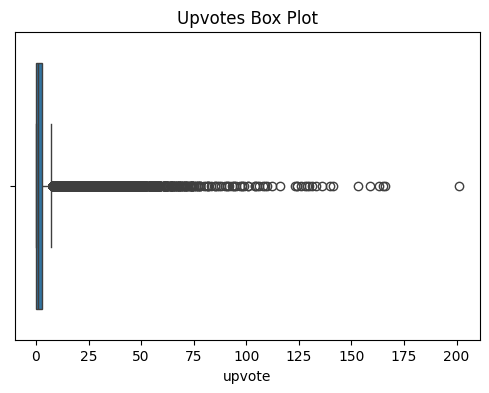

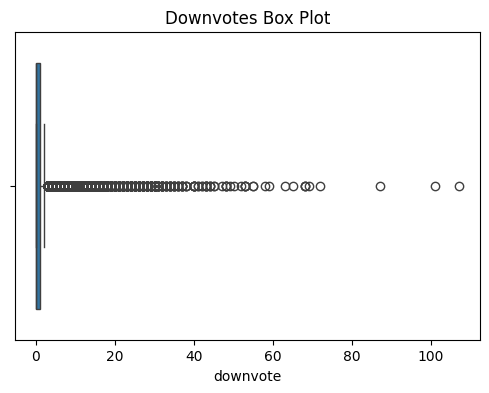

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.boxplot(x=X['upvote'])
plt.title("Upvotes Box Plot")
plt.show()

plt.figure(figsize=(6,4))
sns.boxplot(x=X['downvote'])
plt.title("Downvotes Box Plot")
plt.show()

- The vast majority of posts receive very few upvotes or downvotes.
- A small handful of posts get greater engagement, stretching the data out into a long tail.
- Since, these outliers give our model important information about "viral" posts, we cannot drop them.
- Hence, to deal with this, we will apply a log transformation to shrink those outlier numbers down, bringing them closer to the rest of the distribution.
- We can also skip the math and use tree-based models (like Random Forests or XGBoost). They look at the rank order of data rather than the raw numerical distance, making them completely immune to outlier distortion.

### Plot 2

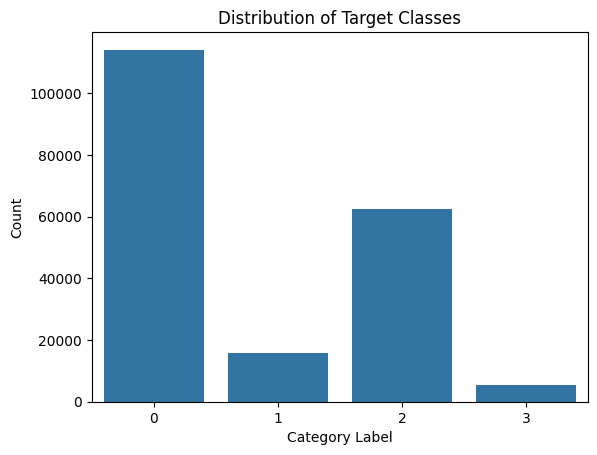

In [18]:
plt.plot(figsize=(6,4))
sns.countplot(x=X['label'])
plt.title("Distribution of Target Classes")
plt.xlabel("Category Label")
plt.ylabel("Count")
plt.show()

- The target categories are not distributed equally across our dataset.
- Category 0 makes up the big majority of the data (with over 100,000 instances).
- Category 3 is extremely underrepresented (around 5,000 instances), making it a tiny fraction of the total data.
- We will handle this imbalance by applying class weighting during training, where we force the model to treat a mistake on Category 3 as much more severe than a mistake on Category 0.
- This also tells us that we cannot use just basic accuracy to evaluate this model, instead, we have to use metrics like the F1-score, Precision, or Recall, which measure how well the model actually handles the minority classes.

### Plot 3

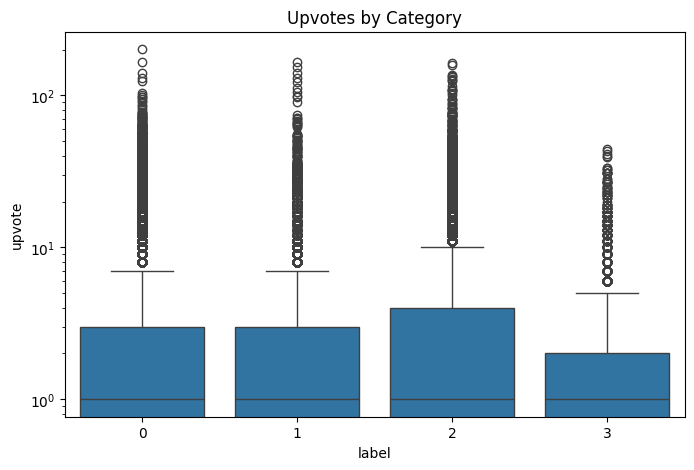

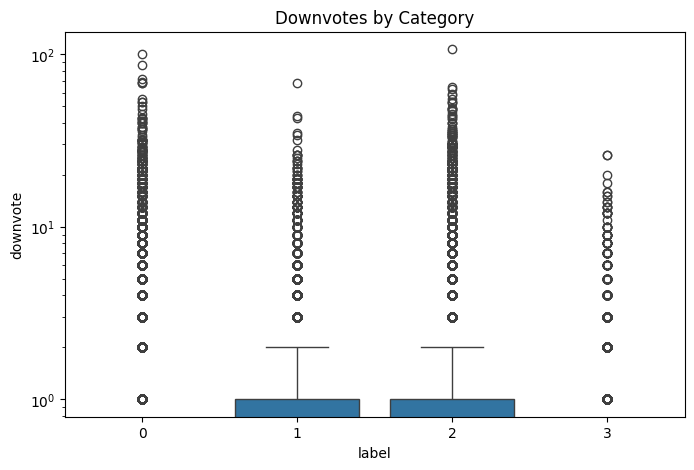

In [19]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=X, x='label', y='upvote')
plt.yscale('log')
plt.title("Upvotes by Category")
plt.show()

plt.figure(figsize=(8, 5))
sns.boxplot(data=X, x='label', y='downvote')
plt.yscale('log')
plt.title("Downvotes by Category")
plt.show()

- Engagement is not random, how people upvote and downvote can depend on the post's category.
- Posts in Category 3 receive significantly fewer upvotes and downvotes compared to the rest of the groups.
- Posts in Category 0 show a much wider spread of downvotes, meaning they attract more varied negative reactions.
- Because upvotes and downvotes behave differently for each specific category, they both act as strong features for our machine learning model. Hence we should absolutely include both upvote and downvote metrics in our final dataset.

### Statiscal Distribution of the Data for Numerical Features

In [20]:
X[['upvote', 'downvote', 'if_1', 'if_2']].describe().round(2)

,upvote,downvote,if_1,if_2
count,197999.00,197999.00,197999.00,197999.00
mean,2.61,0.67,1.91,7.96
std,5.05,2.04,25.64,14.84
min,0.00,0.00,0.00,3.00
25%,0.00,0.00,0.00,4.00
50%,1.00,0.00,0.00,6.00
75%,3.00,1.00,4.00,10.00
max,201.00,107.00,1860.00,1833.00


In the above table if we look at the 75% row of, let say, the **upvote** column, then look at the max row of this column. The 75% of our data is under 3 upvotes, but the max is 201 upvotes, hence, we have mathematically confirmed the extreme **right skew** distribution of our data that we visualized via the chart earlier (same for all these four numerical features).

## Data Preprocessing & Baseline Model

### Handling Outliers

During data visualization, we noticed extreme outliers in four numerical feature: upvote, downvote, if_1, if_2. We will use `np.log1p` transformation here because it shrinks the massive mathematical gap between posts with regular engagements and viral outliers so our model doesn't get too biased by extreme values. This will ensure the algorithm actually learns the category patterns.

In [21]:
numeric_cols = ['upvote', 'downvote', 'if_1', 'if_2']
X[numeric_cols] = np.log1p(X[numeric_cols])
X_test[numeric_cols] = np.log1p(X_test[numeric_cols])

In [22]:
X.head()

,created_date,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,disability,comment,label
0,2024-01-18 08:43:57.397508+00:00,73,0,0,0,0.000000,0.693147,0.0,2.397895,False,She might be a bright spot for a party keou on...,2
1,2024-03-24 21:43:11.490017+00:00,39,0,0,0,1.945910,0.000000,0.0,1.609438,False,"Under Alaska law, a non-tribal member is not b...",0
2,2024-04-24 20:32:17.014931+00:00,31,0,1,1,0.000000,0.000000,0.0,2.397895,False,in the future please spare me your strawman dr...,2
3,2023-05-28 22:00:14.214527+00:00,39,0,0,0,1.791759,0.000000,0.0,2.397895,False,"PS: That should have been ""rot"" instead of ""co...",2
4,2023-09-09 23:12:05.689498+00:00,39,0,0,0,0.000000,0.000000,0.0,2.397895,False,"Today, the confederate flag...tomorrow, the na...",2


### TF-IDF, Standarization and Building a baseline Model

In [23]:
X.select_dtypes(include='object')

,comment
0,She might be a bright spot for a party keou on...
1,"Under Alaska law, a non-tribal member is not b..."
2,in the future please spare me your strawman dr...
3,"PS: That should have been ""rot"" instead of ""co..."
4,"Today, the confederate flag...tomorrow, the na..."
...,...
197995,Why save people who are bent on self-destructi...
197996,Trudeau is not only undemocratic but also innu...
197997,block all exports no humanitarian relief and a...
197998,really black kids seeing that is better than g...


In [24]:
# from sklearn.model_selection import train_test_split
# from sklearn.compose import ColumnTransformer
# from sklearn.feature_extraction.text import TfidfVectorizer
# from sklearn.preprocessing import StandardScaler
# from sklearn.pipeline import Pipeline
# from sklearn.linear_model import LogisticRegression
# from sklearn.metrics import classification_report

# y = X['label']
# X = X.drop(columns=['label'])
# X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# text_col = 'comment'
# num_cols = ['upvote', 'downvote', 'if_1', 'if_2']

# preprocessor = ColumnTransformer(
#     transformers=[
#         ('text', TfidfVectorizer(max_features=10000), text_col),
#         ('numeric', StandardScaler(), num_cols)
#     ]
# )

# baseline_pipeline = Pipeline(steps=[
#     ('preprocessor', preprocessor),
#     ('classifier', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
# ])

# print('Applying preprocessing transformation')
# print('Training the baseline model..')

# baseline_pipeline.fit(X_train, y_train)

# y_pred = baseline_pipeline.predict(X_val)
# print(classification_report(y_val, y_pred))

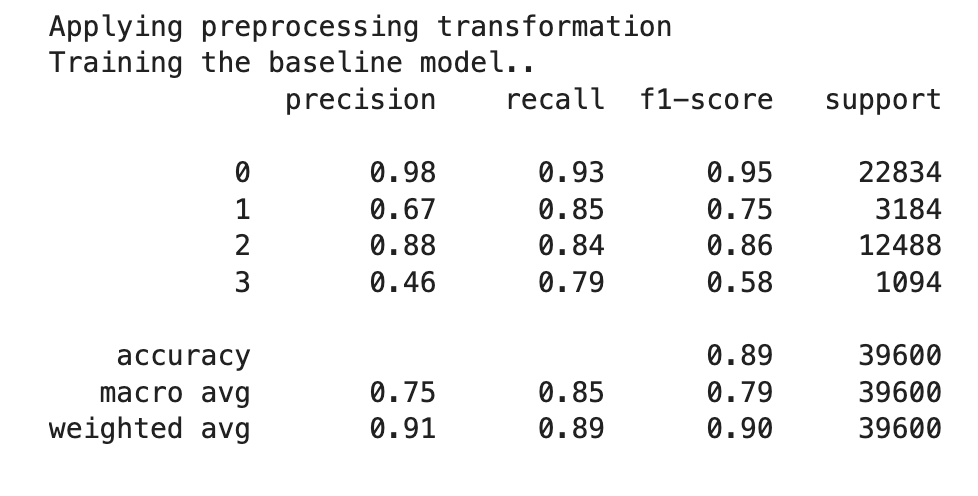

### Feature Extraction

In [25]:
X['hour'] = X['created_date'].dt.hour
X['day_of_week'] = X['created_date'].dt.dayofweek
X['month'] = X['created_date'].dt.month
X['is_weekend'] = X['day_of_week'].apply(lambda x: 1 if x >= 5 else 0)
X = X.drop(columns=['created_date'])

X_test['hour'] = X_test['created_date'].dt.hour
X_test['day_of_week'] = X_test['created_date'].dt.dayofweek
X_test['month'] = X_test['created_date'].dt.month
X_test['is_weekend'] = X_test['day_of_week'].apply(lambda x: 1 if x >= 5 else 0)
X_test = X_test.drop(columns=['created_date'])

print("Time features extracted successfully!")

Time features extracted successfully!


### Feature Selection

In [26]:
# X_train['comment'].apply(lambda x: len(str(x).split())).describe()

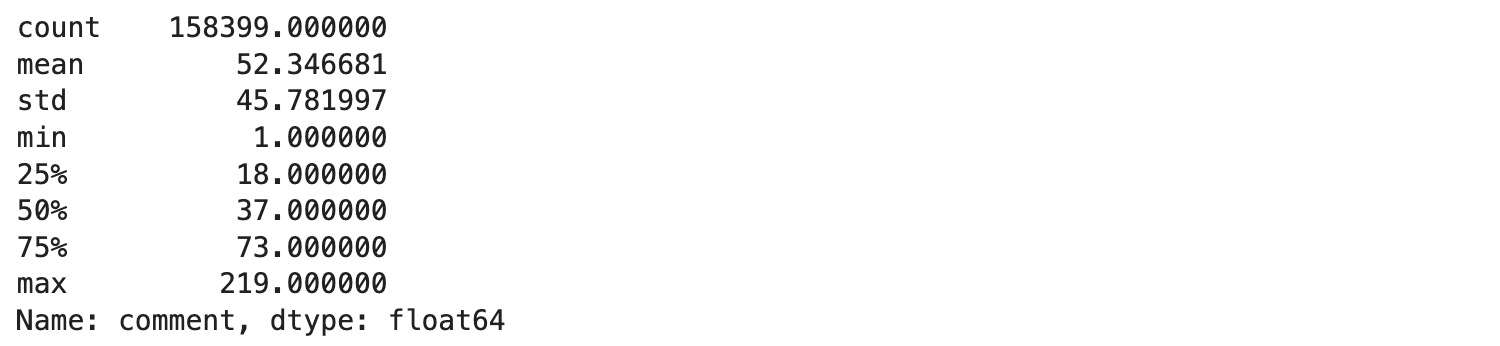

In [27]:
# import joblib
# from sklearn.metrics import f1_score
# from sklearn.pipeline import Pipeline
# from sklearn.model_selection import train_test_split
# from sklearn.compose import ColumnTransformer
# from sklearn.feature_extraction.text import TfidfVectorizer
# from sklearn.feature_selection import SelectKBest, chi2
# from sklearn.preprocessing import StandardScaler

# y = X['label']
# X = X.drop(columns=['label'])
# X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# text_col = 'comment'
# num_cols = ['upvote', 'downvote', 'if_1', 'if_2', 'emoticon_1', 'emoticon_2', 'emoticon_3', 'disability',
#     'hour', 'day_of_week', 'month', 'is_weekend']

# print("--- Loading Saved Best Model ---")
# loaded_pipeline = joblib.load('/kaggle/input/models/aditibindal/best-lgbm-model/scikitlearn/default/1/lgbm_best_model.pkl') 

# tuned_lgbm = loaded_pipeline.named_steps['classifier']

# print("--- Testing best 'k' value on LightGBM ---")
# test_ks = [500, 800, 1000, 1200, 1500, 1800, 2000]

# for k_val in test_ks:
#     temp_text_pipe = Pipeline(steps=[
#         ('tfidf', TfidfVectorizer(max_features=15000)),
#         ('feature_selector', SelectKBest(score_func=chi2, k=k_val)) 
#     ])
    
#     temp_preprocessor = ColumnTransformer(
#         transformers=[
#             ('text', temp_text_pipe, text_col), 
#             ('numeric', StandardScaler(), num_cols)
#         ]
#     )
    
#     temp_pipeline = Pipeline(steps=[
#         ('preprocessor', temp_preprocessor),
#         ('classifier', tuned_lgbm)
#     ])

#     temp_pipeline.fit(X_train, y_train)
#     temp_pred = temp_pipeline.predict(X_val)
    
#     macro_f1 = f1_score(y_val, temp_pred, average='macro')
#     print(f"Features: {k_val} | Local Macro F1: {macro_f1:.5f}")

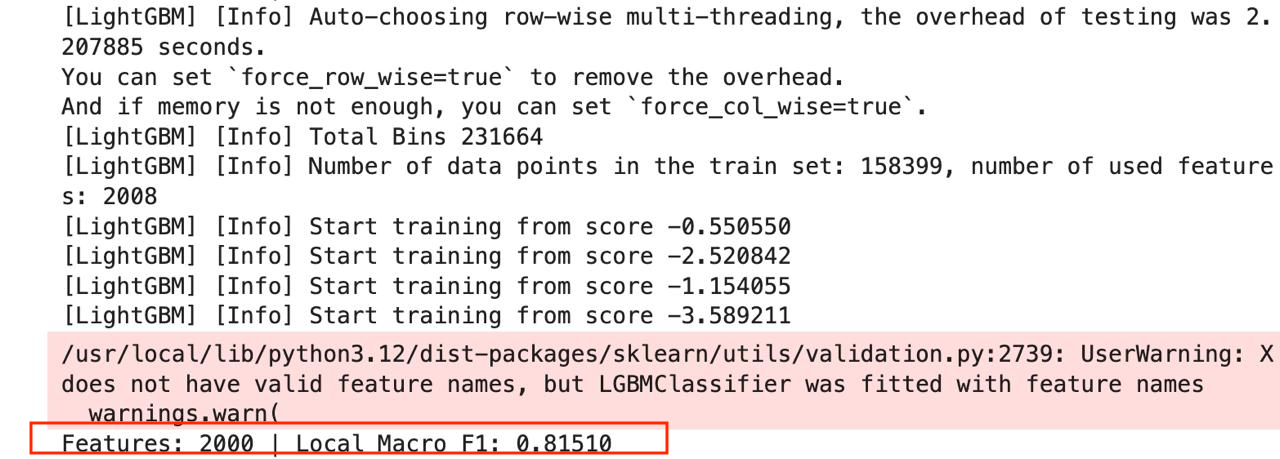

### Retraining the baseline model again with all features (including extracted)

In [28]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

y = X['label']
X = X.drop(columns=['label'])
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

text_col = 'comment'
num_cols = ['upvote', 'downvote', 'if_1', 'if_2', 'emoticon_1', 'emoticon_2', 'emoticon_3', 'disability',
    'hour', 'day_of_week', 'month', 'is_weekend']

text_pipeline = Pipeline(steps=[
    ('tfidf', TfidfVectorizer(max_features=15000)),
    ('feature_selector', SelectKBest(score_func=chi2, k=2000))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('text', text_pipeline, text_col),
        ('numeric', StandardScaler(), num_cols)
    ]
)

baseline_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
])

print('Applying preprocessing transformation')
print('Training the baseline model..')

baseline_pipeline.fit(X_train, y_train)

y_pred = baseline_pipeline.predict(X_val)
print(classification_report(y_val, y_pred))

Applying preprocessing transformation
Training the baseline model..
              precision    recall  f1-score   support

           0       0.98      0.93      0.96     22834
           1       0.67      0.86      0.75      3184
           2       0.89      0.82      0.86     12488
           3       0.41      0.84      0.55      1094

    accuracy                           0.89     39600
   macro avg       0.74      0.86      0.78     39600
weighted avg       0.91      0.89      0.90     39600



As we can observe, Feature engineering yielded no improvements in the linear baseline, proving the dataset contains complex, non-linear feature interactions that require a tree-based architecture.

## Training and Hyperparameter Tuning

In [29]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
import time

rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=1))
])

param_grid = {
    'classifier__n_estimators': [50, 100, 200],
    'classifier__max_depth': [10, 20, 30, None],
    'classifier__min_samples_split': [2, 5, 10]
}

rf_search = RandomizedSearchCV(
    estimator=rf_pipeline, 
    param_distributions=param_grid, 
    n_iter=5,
    cv=3,
    scoring='f1_macro',
    verbose=2,
    random_state=42,
    n_jobs=-1
)

print("--- Starting Hyperparameter Tuning for Random Forest ---")
start_time = time.time()

rf_search.fit(X_train, y_train) 

print(f"\nTuning completed in: {round((time.time() - start_time)/60, 2)} minutes")
print(f"Best Parameters Found: {rf_search.best_params_}\n")

best_rf_model = rf_search.best_estimator_
rf_pred = best_rf_model.predict(X_val)

print("=== Optimized Random Forest Results ===")
print(classification_report(y_val, rf_pred))

--- Starting Hyperparameter Tuning for Random Forest ---
Fitting 3 folds for each of 5 candidates, totalling 15 fits
[CV] END classifier__max_depth=None, classifier__min_samples_split=10, classifier__n_estimators=200; total time=14.9min
[CV] END classifier__max_depth=20, classifier__min_samples_split=10, classifier__n_estimators=100; total time= 1.0min
[CV] END classifier__max_depth=20, classifier__min_samples_split=10, classifier__n_estimators=100; total time= 1.0min
[CV] END classifier__max_depth=20, classifier__min_samples_split=5, classifier__n_estimators=100; total time= 1.1min
[CV] END classifier__max_depth=20, classifier__min_samples_split=5, classifier__n_estimators=100; total time= 1.0min
[CV] END classifier__max_depth=20, classifier__min_samples_split=5, classifier__n_estimators=100; total time= 1.0min
[CV] END classifier__max_depth=30, classifier__min_samples_split=10, classifier__n_estimators=200; total time= 3.1min
[CV] END classifier__max_depth=30, classifier__min_samples

The Random Forest tuning showed that while **bagging** hits 90% accuracy, it struggles to capture rare classes like Category 3 within the 10,000-column sparse text matrix, leading to a big drop in recall.

We are now transitioning to **Boosting** because it builds trees sequentially to specifically fix the errors made on those rare classes. We specifically chose LightGBM over XGBoost or CatBoost because it uses Leaf-wise growth making it the fastest and most memory-efficient model for handling the massive, sparse TF-IDF matrices in our dataset.

In [30]:
from lightgbm import LGBMClassifier

lgbm_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor), 
    ('classifier', LGBMClassifier(
        is_unbalance=True, 
        random_state=42, 
        n_jobs=1,
        importance_type='gain'
    ))
])

param_grid = {
    'classifier__n_estimators': [100, 200, 300],
    'classifier__learning_rate': [0.01, 0.05, 0.1], 
    'classifier__num_leaves': [31, 63, 90],
    'classifier__reg_alpha': [0.1, 0.5],
    'classifier__reg_lambda': [0.1, 0.5],
    'classifier__colsample_bytree': [0.6, 0.8, 1.0]
}

lgbm_search = RandomizedSearchCV(
    estimator=lgbm_pipeline, 
    param_distributions=param_grid, 
    n_iter=10,          
    cv=3,              
    scoring='f1_macro',
    verbose=2,         
    random_state=42,
    n_jobs=-1
)

print("--- Starting Hyperparameter Tuning for LightGBM ---")
start_time = time.time()

lgbm_search.fit(X_train, y_train) 

print(f"\nTuning completed in: {round((time.time() - start_time)/60, 2)} minutes")
print(f"Best Parameters Found: {lgbm_search.best_params_}\n")

best_lgbm_model = lgbm_search.best_estimator_
lgbm_pred = best_lgbm_model.predict(X_val)

print("=== Optimized LightGBM Results ===")
print(classification_report(y_val, lgbm_pred))

--- Starting Hyperparameter Tuning for LightGBM ---
Fitting 3 folds for each of 10 candidates, totalling 30 fits


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 2.572003 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 231664
[LightGBM] [Info] Number of data points in the train set: 158399, number of used features: 2008
[LightGBM] [Info] Start training from score -0.550550
[LightGBM] [Info] Start training from score -2.520842
[LightGBM] [Info] Start training from score -1.154055
[LightGBM] [Info] Start training from score -3.589211

Tuning completed in: 27.69 minutes
Best Parameters Found: {'classifier__reg_lambda': 0.1, 'classifier__reg_alpha': 0.1, 'classifier__num_leaves': 63, 'classifier__n_estimators': 200, 'classifier__learning_rate': 0.1, 'classifier__colsample_bytree': 0.8}



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


=== Optimized LightGBM Results ===
              precision    recall  f1-score   support

           0       0.98      0.95      0.96     22834
           1       0.78      0.78      0.78      3184
           2       0.85      0.92      0.89     12488
           3       0.74      0.55      0.63      1094

    accuracy                           0.91     39600
   macro avg       0.84      0.80      0.82     39600
weighted avg       0.92      0.91      0.91     39600



## Ensemble Models (Voting)

In [31]:
from sklearn.ensemble import StackingClassifier

print("--- Building the Stacking Ensemble ---")

text_pipeline_ngrams = Pipeline(steps=[
    ('tfidf', TfidfVectorizer(max_features=25000, ngram_range=(1, 2))),
    ('feature_selector', SelectKBest(score_func=chi2, k=2500))
])
preprocessor_ngrams = ColumnTransformer(
    transformers=[('text', text_pipeline_ngrams, text_col), ('numeric', StandardScaler(), num_cols)]
)
lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor_ngrams),
    ('classifier', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
])

text_pipeline_unigrams = Pipeline(steps=[
    ('tfidf', TfidfVectorizer(max_features=15000)),
    ('feature_selector', SelectKBest(score_func=chi2, k=2000))
])
preprocessor_unigrams = ColumnTransformer(
    transformers=[('text', text_pipeline_unigrams, text_col), ('numeric', StandardScaler(), num_cols)]
)

lgbm_pipeline = Pipeline(steps=[
            ('preprocessor', preprocessor_unigrams),
            ('classifier', best_lgbm_model.named_steps['classifier'])
        ])

stacking_model = StackingClassifier(
    estimators=[
        ('lr_ngrams', lr_pipeline), 
        ('lgbm_unigrams', lgbm_pipeline)
    ],
    final_estimator=LogisticRegression(),
    cv=3,
    n_jobs=-1
)

stacking_model.fit(X_train, y_train)

stacking_pred = stacking_model.predict(X_val)
print("=== Stacking Results ===")
print(classification_report(y_val, stacking_pred))

--- Building the Stacking Ensemble ---
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 2.878937 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 180660
[LightGBM] [Info] Number of data points in the train set: 105600, number of used features: 1864
[LightGBM] [Info] Start training from score -0.550557
[LightGBM] [Info] Start training from score -2.520769
[LightGBM] [Info] Start training from score -1.154071
[LightGBM] [Info] Start training from score -3.589103
[CV] END classifier__colsample_bytree=0.8, classifier__learning_rate=0.01, classifier__n_estimators=300, classifier__num_leaves=31, classifier__reg_alpha=0.1, classifier__reg_lambda=0.1; total time= 4.2min
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 2.868777 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is no

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 3.136453 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 185478
[LightGBM] [Info] Number of data points in the train set: 105599, number of used features: 1894
[LightGBM] [Info] Start training from score -0.550547
[LightGBM] [Info] Start training from score -2.520878
[LightGBM] [Info] Start training from score -1.154031
[LightGBM] [Info] Start training from score -3.589436
[CV] END classifier__colsample_bytree=0.8, classifier__learning_rate=0.01, classifier__n_estimators=100, classifier__num_leaves=31, classifier__reg_alpha=0.1, classifier__reg_lambda=0.1; total time= 1.6min
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 3.043476 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=t

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


=== Stacking Results ===
              precision    recall  f1-score   support

           0       0.98      0.95      0.96     22834
           1       0.78      0.79      0.78      3184
           2       0.86      0.91      0.89     12488
           3       0.68      0.64      0.66      1094

    accuracy                           0.91     39600
   macro avg       0.83      0.82      0.82     39600
weighted avg       0.92      0.91      0.92     39600



In [32]:
import joblib
# Save the model to disk
joblib.dump(stacking_model, 'stacked_lr_lgbm.pkl')

['stacked_lr_lgbm.pkl']

## Comparing Model Performances

In [33]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

model_predictions = {
    "Baseline (Logistic Reg)": y_pred,
    "Tuned Random Forest": rf_pred,
    "Tuned LightGBM": lgbm_pred,
    "Stacking Classifier": stacking_pred
}

results_list = []

for model_name, preds in model_predictions.items():
    acc = accuracy_score(y_val, preds)
    prec = precision_score(y_val, preds, average='macro', zero_division=0)
    rec = recall_score(y_val, preds, average='macro', zero_division=0)
    f1 = f1_score(y_val, preds, average='macro', zero_division=0)
    
    results_list.append({
        "Model": model_name,
        "Accuracy": acc,
        "Macro Precision": prec,
        "Macro Recall": rec,
        "Macro F1-Score": f1
    })

results_df = pd.DataFrame(results_list)
results_df = results_df.sort_values(by="Macro F1-Score", ascending=False).reset_index(drop=True)

display(results_df)

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1-Score
0,Stacking Classifier,0.914874,0.825621,0.821168,0.822942
1,Tuned LightGBM,0.914722,0.838897,0.799484,0.815100
2,Baseline (Logistic Reg),0.889470,0.737290,0.862520,0.778172
3,Tuned Random Forest,0.902121,0.821770,0.753734,0.777271


## Generating Predictions on Test Set

In [34]:
sample = pd.read_csv('/kaggle/input/comment-category-prediction-challenge/Sample.csv')
sample.shape

(102000, 2)

In [35]:
test_preds = stacking_model.predict(X_test)

sample['label'] = test_preds
sample.to_csv('submission.csv', index=False)
print("Submission file saved successfully!")

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Submission file saved successfully!
